# AdEase Time Series Analysis & Forecasting

## Project Overview
This project analyzes the daily traffic data for AdEase campaigns (represented as pages) to identify trends, seasonality, and the impact of exogenous marketing campaigns.
We aim to:
1. Explore the dataset and identify high-traffic pages.
2. Analyze the impact of the binary Exogenous component (Campaign Events).
3. Build a Time Series Forecasting model for the top performing page.

## Dataset
- **train_1.csv**: Daily traffic data for various Wikipedia pages (Campaigns).
- **Exog_Campaign_eng**: Binary exogenous variable indicating specific campaign events.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)


In [2]:
# Load Datasets
# Using nrows=None to load full dataset, but be mindful of memory. 
# If memory is an issue, consider reading in chunks or a subset.
df = pd.read_csv('train_1.csv')
exog = pd.read_csv('Exog_Campaign_eng')

# The Exogenous file doesn't have a proper header in some versions, let's check
print("Exog Shape:", exog.shape)
print("Traffic Data Shape:", df.shape)

# Create a date range based on columns
date_cols = df.columns[1:]
start_date = date_cols[0]
end_date = date_cols[-1]
print(f"Date Range: {start_date} to {end_date}")
print(f"Total Days: {len(date_cols)}")


Exog Shape: (550, 1)
Traffic Data Shape: (145063, 551)
Date Range: 2015-07-01 to 2016-12-31
Total Days: 550


In [3]:
# handle missing values (Assume 0 for missing traffic)
df = df.fillna(0)

# Calculate Total Views for each page to find the most popular ones
df['Total_Views'] = df[date_cols].sum(axis=1)
top_pages = df.sort_values('Total_Views', ascending=False).head(5)

print("Top 5 Pages by Traffic:")
for idx, row in top_pages.iterrows():
    print(f"- {row['Page']} : {row['Total_Views']:.0f} views")


Top 5 Pages by Traffic:
- Main_Page_en.wikipedia.org_all-access_all-agents : 12066181102 views
- Main_Page_en.wikipedia.org_desktop_all-agents : 8774497458 views
- Main_Page_en.wikipedia.org_mobile-web_all-agents : 3153984882 views
- Wikipedia:Hauptseite_de.wikipedia.org_all-access_all-agents : 1603934248 views
- Special:Search_en.wikipedia.org_all-access_all-agents : 1304079353 views


## Exploratory Data Analysis (EDA)
Let's visualize the traffic of the Top 5 Pages over time.


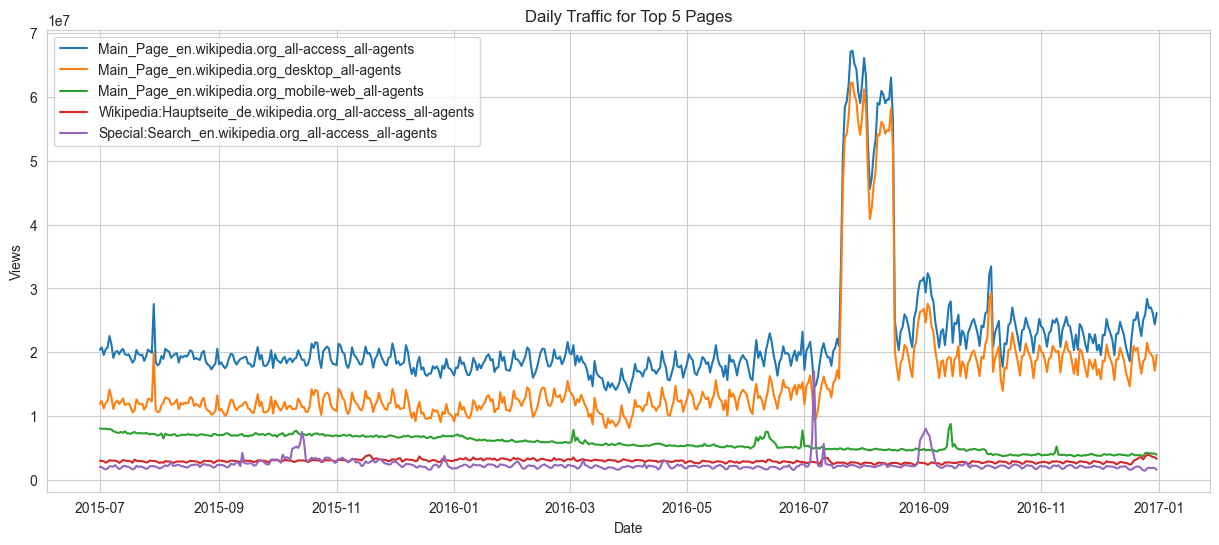

In [4]:
# Transpose for plotting
top_pages_T = top_pages[date_cols].T
top_pages_T.index = pd.to_datetime(top_pages_T.index)
top_pages_T.columns = top_pages['Page'].values

# Plot
plt.figure(figsize=(15, 6))
for col in top_pages_T.columns:
    plt.plot(top_pages_T.index, top_pages_T[col], label=col)

plt.title('Daily Traffic for Top 5 Pages')
plt.xlabel('Date')
plt.ylabel('Views')
plt.legend()
plt.show()


## Impact of Exogenous Variable
Let's see if the Exogenous variable (Campaign Active) correlates with higher traffic.


Exog length matches date columns.


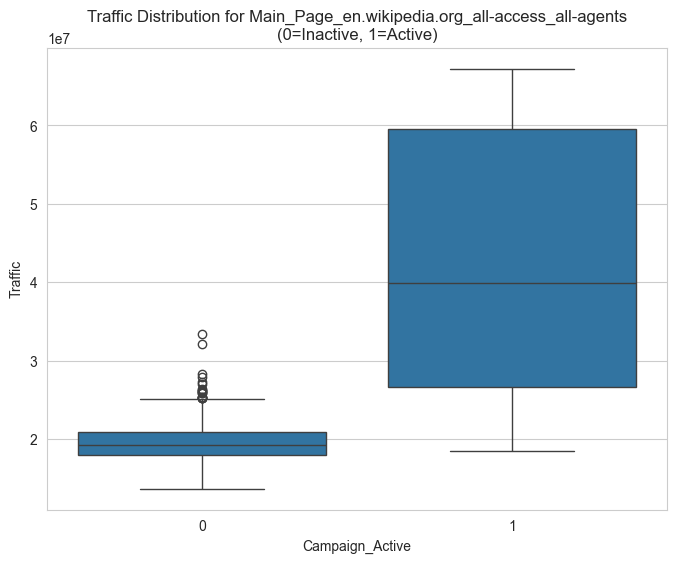

Mean Traffic by Campaign Status:
Campaign_Active
0    1.967469e+07
1    4.273211e+07
Name: Traffic, dtype: float64


In [5]:
# Prepare Exogenous Data
# Assuming the exog file corresponds to the dates 2015-07-01 to 2016-12-31
exog_values = exog.iloc[:, 0].values

# Ensure length matches
if len(exog_values) == len(date_cols):
    print("Exog length matches date columns.")
else:
    print(f"Mismatch: Exog {len(exog_values)} vs Dates {len(date_cols)}")
    # Adjust if necessary (e.g. if header issues effectively reduced rows)
    # For now assuming straightforward match or slight adjustment
    exog_values = exog_values[:len(date_cols)]

# Analyze Mean Traffic on Active vs Inactive Sample Days (Top Page)
top_page_name = top_pages.iloc[0]['Page']
top_page_series = top_pages.iloc[0][date_cols].values.astype(float)

df_analysis = pd.DataFrame({
    'Date': pd.to_datetime(date_cols),
    'Traffic': top_page_series,
    'Campaign_Active': exog_values
})

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Campaign_Active', y='Traffic', data=df_analysis)
plt.title(f'Traffic Distribution for {top_page_name}\n(0=Inactive, 1=Active)')
plt.show()

print("Mean Traffic by Campaign Status:")
print(df_analysis.groupby('Campaign_Active')['Traffic'].mean())


## Time Series Forecasting (ARIMA)
We will forecast the traffic for the Top 1 Page using ARIMA.


Train size: 495, Test size: 55
                               SARIMAX Results                                
Dep. Variable:                Traffic   No. Observations:                  495
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -7981.161
Date:                Sat, 03 Jan 2026   AIC                          15974.323
Time:                        15:37:16   BIC                          15999.538
Sample:                             0   HQIC                         15984.222
                                - 495                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1452      0.020      7.104      0.000       0.105       0.185
ar.L2         -0.0235      0.036     -0.657      0.511      -0.094       0.047
ar.L3         -0.0900

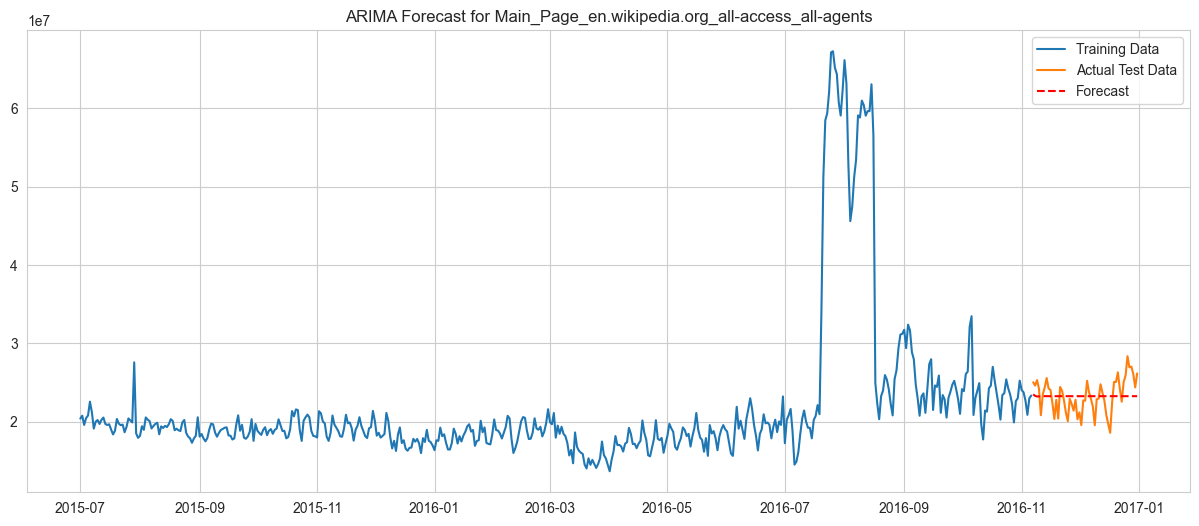

RMSE: 2145049.74


In [6]:
# Split Data into Train and Test
train_size = int(len(df_analysis) * 0.9)
train, test = df_analysis['Traffic'][:train_size], df_analysis['Traffic'][train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Train ARIMA Model (Auto-Regressive Integrated Moving Average)
# Using a simple (5,1,0) order as a baseline
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

# Forecast
forecast_steps = len(test)
forecast = model_fit.forecast(steps=forecast_steps)

# Plot Results
plt.figure(figsize=(15, 6))
plt.plot(df_analysis['Date'][:train_size], train, label='Training Data')
plt.plot(df_analysis['Date'][train_size:], test, label='Actual Test Data')
plt.plot(df_analysis['Date'][train_size:], forecast, label='Forecast', linestyle='--', color='red')
plt.title(f'ARIMA Forecast for {top_page_name}')
plt.legend()
plt.show()

# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.2f}")
